7735
dataset 1, mean p-value: 0.10266
dataset 2, mean p-value: 0.15897
dataset 3, mean p-value: 0.03030
dataset 4, mean p-value: 0.05634
dataset 5, mean p-value: 0.07272
dataset 6, mean p-value: 0.02529
dataset 7, mean p-value: 0.08647
stacked datasets, mean p-value: 0.05132


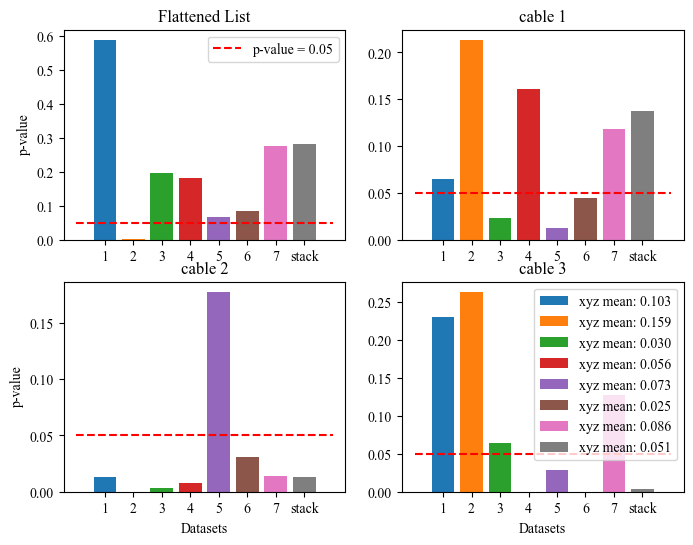

In [14]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Times New Roman"

from data_functions import parse_dataset
    # random w/ neighbors
datasets = [
        "./data/dataset_1051_rand3N_2024-02-07T114202.txt", # ~500
        "./data/dataset_1051_rand3N_2024-02-07T124945.txt",
        "./data/dataset_1049_rand3N_2024-02-07T144446.txt",
        "./data/dataset_1047_rand3N_2024-02-07T155230.txt", # ~900
        "./data/dataset_7687_rand3N_2024-02-09T113646.txt", # also aprox 1100
        "./data/dataset_1047_rand3N_2024-02-09T130942.txt",
        "./data/dataset_841_rand3N_2024-02-09T164215.txt",
        "./data/dataset_1201_2023-12-19T155359.txt", # for testing, random
        "./data/dataset_1200_2023-12-13T161233.txt",
        "./data/dataset_1200_2023-12-15T145833.txt", # many outliers
        "./data/dataset_1201_2023-12-19T155359.txt",
        "./data/dataset_1100_2024-02-07T165437.txt", # without extreme outlier
        "./data/dataset_1101_2024-02-09T103741.txt",
        "./data/dataset_1101_2024-02-09T141149.txt", # ~700
        ]

neib_traj, neib_refT, neib_pos = parse_dataset(datasets[0])
rand_traj = np.empty((0, 3))
neib_traj_stack = np.empty((0, 3))
for ds in datasets:
    if "rand3N" not in ds:
        rand_traj = np.vstack((rand_traj, parse_dataset(ds)[0]))
    else:
        neib_traj_stack = np.vstack((neib_traj_stack, parse_dataset(ds)[0]))

print(len(rand_traj))
rand_traj_flat = rand_traj.flatten()
fig, ax = plt.subplots(2, 2, figsize=(8,6))

num_rand3n = 0
sum_p = np.zeros((4, ))
for i, ds in enumerate(datasets):
    if "rand3N" in ds:
        num_rand3n += 1
        neib_traj, _, _ = parse_dataset(ds)

        pvalues_xyz = [
            stats.ks_2samp(rand_traj[:, 0], neib_traj[:, 0])[1],
            stats.ks_2samp(rand_traj[:, 1], neib_traj[:, 1])[1],
            stats.ks_2samp(rand_traj[:, 2], neib_traj[:, 2])[1],
        ]

        pvalue_flat = stats.ks_2samp(rand_traj_flat, neib_traj.ravel())[1]

        sum_p[0] += pvalue_flat
        sum_p[1:] += pvalues_xyz

        ax[0, 0].bar([i+1], pvalue_flat)
        ax[0, 1].bar([i+1], pvalues_xyz[0])
        ax[1, 0].bar([i+1], pvalues_xyz[1])
        ax[1, 1].bar([i+1], pvalues_xyz[2], label=f"xyz mean: {sum(pvalues_xyz) / 3:.3f}")

        print(f'dataset {num_rand3n}, mean p-value: {sum(pvalues_xyz) / 3:.5f}')

pvalues_xyz = [
    stats.ks_2samp(rand_traj[:, 0], neib_traj_stack[:, 0])[1],
    stats.ks_2samp(rand_traj[:, 1], neib_traj_stack[:, 1])[1],
    stats.ks_2samp(rand_traj[:, 2], neib_traj_stack[:, 2])[1],
]

num_rand3n += 1
print(f'stacked datasets, mean p-value: {sum(pvalues_xyz) / 3:.5f}')
ax[0, 0].bar([num_rand3n], stats.ks_2samp(rand_traj_flat, neib_traj_stack.ravel())[1])
ax[0, 1].bar([num_rand3n], pvalues_xyz[0])
ax[1, 0].bar([num_rand3n], pvalues_xyz[1])
ax[1, 1].bar([num_rand3n], pvalues_xyz[2], label=f"xyz mean: {sum(pvalues_xyz) / 3:.3f}")

ax[1,1].legend()

# num_rand3n += 1
# print(f'mean of dataset results (xyz), mean p-value: {sum(sum_p[1:]) / num_rand3n / 3:.5f}')
# ax[0, 0].bar([num_rand3n], sum_p[0] / (num_rand3n - 2))
# ax[0, 1].bar([num_rand3n], sum_p[1] / (num_rand3n - 2))
# ax[1, 0].bar([num_rand3n], sum_p[2] / (num_rand3n - 2))
# ax[1, 1].bar([num_rand3n], sum_p[3] / (num_rand3n - 2))

ax[0, 0].hlines(0.05, 0, num_rand3n+1, linestyle='dashed', color='red', label='p-value = 0.05')
ax[0, 0].set_title("Flattened List")
# ax[0, 0].set_xlabel("Datasets")
ax[0, 0].set_ylabel("p-value")
ax[0, 1].hlines(0.05, 0, num_rand3n+1, linestyle='dashed', color='red')
ax[0, 1].set_title("cable 1")
# ax[0, 1].set_xlabel("Datasets")
# ax[0, 1].set_ylabel("p-value")
ax[1, 0].hlines(0.05, 0, num_rand3n+1, linestyle='dashed', color='red')
ax[1, 0].set_title("cable 2")
ax[1, 0].set_xlabel("Datasets")
ax[1, 0].set_ylabel("p-value")
ax[1, 1].hlines(0.05, 0, num_rand3n+1, linestyle='dashed', color='red')
ax[1, 1].set_title("cable 3")
ax[1, 1].set_xlabel("Datasets")
# ax[1, 1].set_ylabel("p-value")

xticks = (list(range(1, num_rand3n + 1)), list(map(str, range(1, num_rand3n ))) + ['stack']) # , 'mean'
# xticks = (list(range(1, num_rand3n + 1)), list(map(str, range(1, num_rand3n - 1))) + ['stack', 'mean']) #
ax[0, 0].set_xticks(xticks[0], labels=xticks[1])
ax[0, 1].set_xticks(xticks[0], labels=xticks[1])
ax[1, 0].set_xticks(xticks[0], labels=xticks[1])
ax[1, 1].set_xticks(xticks[0], labels=xticks[1])

ax[0,0].legend()

In [93]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

from data_functions import parse_dataset, polaris2base
    # random w/ neighbors
datasets = [
        "./data/dataset_1051_rand3N_2024-02-07T114202.txt", # ~500
        "./data/dataset_1051_rand3N_2024-02-07T124945.txt",
        "./data/dataset_1049_rand3N_2024-02-07T144446.txt",
        "./data/dataset_1047_rand3N_2024-02-07T155230.txt", # ~900
        "./data/dataset_7687_rand3N_2024-02-09T113646.txt", # also aprox 1100
        "./data/dataset_1047_rand3N_2024-02-09T130942.txt",
        "./data/dataset_841_rand3N_2024-02-09T164215.txt",
        "./data/dataset_1201_2023-12-19T155359.txt", # for testing, random
        "./data/dataset_1200_2023-12-13T161233.txt",
        "./data/dataset_1200_2023-12-15T145833.txt", # many outliers
        "./data/dataset_1201_2023-12-19T155359.txt",
        "./data/dataset_1100_2024-02-07T165437.txt", # without extreme outlier
        "./data/dataset_1101_2024-02-09T103741.txt",
        "./data/dataset_1101_2024-02-09T141149.txt", # ~700
        ]


datasets = [dataset for dataset in datasets if 'rand3N' in dataset] # neib
# datasets = [dataset for dataset in datasets if 'rand3N' not in dataset] # rand

dir_flag = True
pos_base = np.empty((0, 3))
# diff = np.empty((0, 3))

for dataset in datasets:
    traj, ref_T, pos = parse_dataset(dataset)
    _, pos_base, _ = polaris2base(traj, ref_T, pos)

    means = np.empty((len(pos_base[1:]) // 7 + 1, 3))
    rp_p_n = np.zeros((len(pos_base[1:]) // 7 + 1, 4, 3))
    dirs = np.zeros((len(pos_base[1:]) // 7 + 1, 4, 3))
    rp_range = range(1, len(pos_base) - 7, 7) if len(pos_base[:1]) % 7 != 0 else range(1, len(pos_base), 7)
    for n, i in enumerate(rp_range):
        means[n] = np.mean(pos_base[i:i+7:2], axis=0)
        rp_p_n[n] = pos_base[i:i+7:2]
        dirs[n] = rp_p_n[n] - pos_base[i-1:i+6:2,:]
        if dir_flag:
            dirs[n] = np.array([dirs[n, j] / np.linalg.norm(dirs[n, j]) for j in range(4)])
        # diff
    # print(len(means), len(rp_p_n), len(dirs))
    # print(means[-3:])
    # print(rp_p_n[-3:])
    # print(dirs[-3:])

    means = means[:n]
    rp_p_n = rp_p_n[:n]
    dirs = dirs[:n]
    # print(n, i)
    # print(len(means), len(rp_p_n), len(dirs))
    diff = np.array([rp_p_n[i,:] - means[i] for i in range(len(means))]).reshape(-1, 3)
    dirs = dirs.reshape(-1, 3)
    corr_mat = np.corrcoef(diff.T, dirs.T)
    print("mean         ", np.mean(corr_mat))
    print("mean w/o diag", (np.sum(corr_mat) - np.trace(corr_mat)) / (len(corr_mat) * (len(corr_mat) - 1)))
    print("det          ", np.linalg.det(corr_mat))
    print("")
    # print(corr_mat)
    # fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # r_squared_values = []

    # for i, coord in enumerate(['x', 'y', 'z']):
    #     ax = axes[i]
    #     ax.scatter(diff[:, i], dirs[:, i], color='blue', alpha=0.5)
    #     ax.set_xlabel(f'Diff {coord}')
    #     ax.set_ylabel(f'Dirs {coord}')
    #     ax.grid(True)
    #     # Overlay the regression line
    #     m, b = np.polyfit(diff[:, i], dirs[:, i], 1)
    #     ax.plot(diff[:, i], m * diff[:, i] + b, color='red')

    #     data1_coord = diff[:, i]
    #     data2_coord = dirs[:, i]
        
    #     # Calculate the residuals
    #     residuals = data2_coord - (m * data1_coord + b)
        
    #     # Calculate the total sum of squares
    #     total_sum_of_squares = np.sum((data2_coord - np.mean(data2_coord)) ** 2)
        
    #     # Calculate the residual sum of squares
    #     residual_sum_of_squares = np.sum(residuals ** 2)
        
    #     # Calculate R-squared
    #     r_squared = 1 - (residual_sum_of_squares / total_sum_of_squares)
        
    #     # Append the R-squared value to the list
    #     r_squared_values.append(r_squared)

    # plt.suptitle('Scatter plot and linear regression line for each pair of coordinates')
    # plt.tight_layout()
    # print(r_squared_values)

    
# correlação entre (diff do ponto rp_p_1 / média dos rp_p_n aos pontos rp_p_n) e (dir/vetor de deslocamento para rp_p_n)



mean          0.2419979272985129
mean w/o diag 0.09039751275821549
det           0.4492705980385122

mean          0.25536022411113635
mean w/o diag 0.10643226893336362
det           0.46497534386952605

mean          0.14348194125540328
mean w/o diag -0.027821670493516047
det           0.4591884359038788

mean          0.23028564380178945
mean w/o diag 0.07634277256214735
det           0.7537788562995668

mean          0.23847664385052564
mean w/o diag 0.08617197262063077
det           0.4886249294186283

mean          0.2014484795620094
mean w/o diag 0.04173817547441129
det           0.7826455439051057

mean          0.22918867419138905
mean w/o diag 0.07502640902966687
det           0.5277583607671379



In [ ]:
# random data collection

# mean          0.24604309285206316
# mean w/o diag 0.0952517114224758
# det           0.30961910529262804

# mean          0.2565367708718013
# mean w/o diag 0.10784412504616156
# det           0.3087687698921784

# mean          0.2415489567953868
# mean w/o diag 0.08985874815446415
# det           0.30450739652055225

# mean          0.24604309285206316
# mean w/o diag 0.0952517114224758
# det           0.30961910529262804

# mean          0.23325811401274757
# mean w/o diag 0.07990973681529709
# det           0.27070571002969424

# mean          0.25683114315641487
# mean w/o diag 0.10819737178769782
# det           0.3623793096102664

# mean          0.2355121695086885
# mean w/o diag 0.08261460341042624
# det           0.287644856032661